## Experiment Vases and Faces

Button(description='Finished, i see what it is! Save clicks and exit.', layout=Layout(height='40px', width='10…

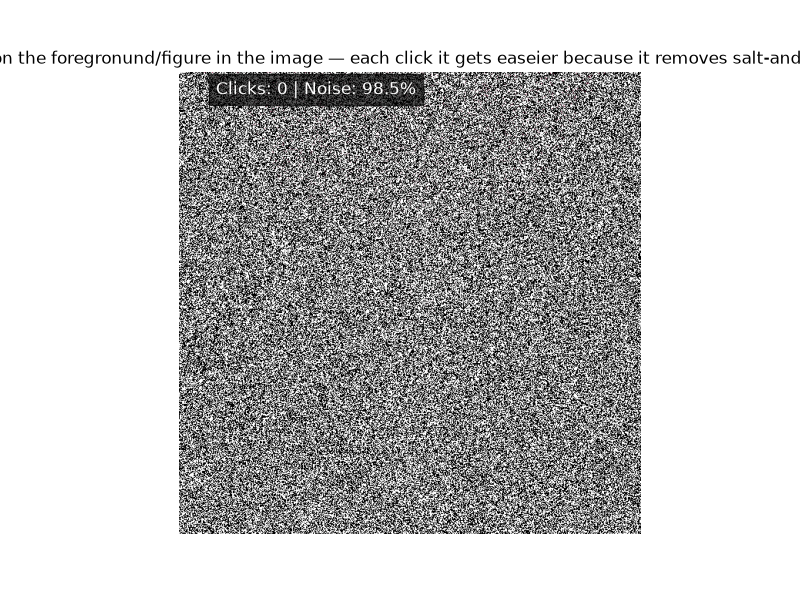

In [ ]:
%matplotlib widget

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

import ipywidgets as widgets
from IPython.display import display
import ipympl

image_path = Path("faces_vase_color.jpg")
if not image_path.exists():
    image_path = Path.cwd() / "faces_vase_color.jpg"
if not image_path.exists():
    raise FileNotFoundError("Could not find faces_vase_color.jpg next to the notebook.")

original = np.asarray(Image.open(image_path).convert("RGB"))
rng = np.random.default_rng()
clicks = []
click_count = 0

fig, ax = plt.subplots(figsize=(8, 6))

button = widgets.Button(description="Finished, i see what it is! Save clicks and exit.",
    layout=widgets.Layout(width="100%", height="40px"))
display(button)

def on_button_click(b):
    save_clicks(clicks, image_path.stem + "_clicks.txt")
    plt.close(fig)

def save_clicks(clicks, output_path):
    with open(output_path, "w", encoding="utf-8") as file:
        for x, y in clicks:
            file.write(f"{x:.2f},{y:.2f}\n")
button.on_click(
    lambda event: save_clicks(clicks, image_path.stem + "_clicks.txt")
)
score_text = ax.text(
    0.08, 0.98, "Clicks: 0 | Noise: 98.5%",
    transform=ax.transAxes,
    va="top",
    color="white",
    fontsize=12,
    bbox={"facecolor": "black", "alpha": 0.65, "pad": 5},
)

def add_noise(image, amount):
    noisy = image.copy()
    mask = rng.random(image.shape[:2]) < amount
    salt = rng.random(image.shape[:2]) < 0.5
    noisy[mask & salt] = 255
    noisy[mask & ~salt] = 0
    return noisy

fig.canvas.toolbar_visible = False
fig.canvas.header_visible = False
fig.canvas.footer_visible = False
ax.set_axis_off()
image_artist = ax.imshow(original)
noise_amount = (1 - (click_count + 1)  * 0.015)
image_artist.set_data(add_noise(original, noise_amount))



ax.set_title("Try to click on the foregronund/figure inside the image.")

def on_click(event):
    global click_count
    if event.inaxes is not ax or event.xdata is None or event.ydata is None:
        return

    click_count += 1
    clicks.append((event.xdata, event.ydata))
    noise_amount = (1 - (click_count + 1)  * 0.015)
    image_artist.set_data(add_noise(original, noise_amount))
    score_text.set_text(
        f"Clicks: {click_count} | Noise: {noise_amount:.1%}"
    )
    ax.plot(event.xdata, event.ydata, "r+", ms=12, mew=2)
    fig.canvas.draw_idle()

fig.canvas.mpl_connect("button_press_event", on_click)
plt.show()
